In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path("/content/drive/MyDrive/nextgen_nlp_final/artifacts")

df_sent = pd.read_parquet(ARTIFACTS_DIR / "article_sentiment.parquet")
df_entities = pd.read_parquet(ARTIFACTS_DIR / "entities_raw.parquet")



print(df_sent.shape)
print(df_entities.shape)

(33765, 8)
(387787, 8)


In [8]:
df_sent.columns.tolist()

['date',
 'title_clean',
 'clean_text',
 'topic',
 'topic_name',
 'industry_label',
 'sentiment_score',
 'sentiment']

In [7]:
df_entities.columns.tolist()

['date',
 'topic',
 'topic_name',
 'industry_label',
 'title_clean',
 'entity_text',
 'entity_label',
 'score']

In [9]:
df_entities_sent = df_entities.merge(
    df_sent[["title_clean", "sentiment", "sentiment_score"]],
    on="title_clean",
    how="left"
)

df_entities_sent.head()

,date,topic,topic_name,industry_label,title_clean,entity_text,entity_label,score,sentiment,sentiment_score
0,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999630,positive,0.574204
1,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.982130,positive,0.574204
2,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,The DBT News,ORG,0.992576,positive,0.574204
3,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999625,positive,0.574204
4,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.861583,positive,0.574204


In [10]:
df_entities_sent.columns

Index(['date', 'topic', 'topic_name', 'industry_label', 'title_clean',
       'entity_text', 'entity_label', 'score', 'sentiment', 'sentiment_score'],
      dtype='object')

In [11]:
df_entities_org = df_entities_sent[
    df_entities_sent["entity_label"] == "ORG"
].copy()

In [12]:
entity_sentiment = (
    df_entities_org
    .groupby(["entity_text", "sentiment"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

entity_sentiment.head(20)

,entity_text,sentiment,count
45981,OpenAI,neutral,19238
47099,PRNewswire,positive,17647
45982,OpenAI,positive,9308
5358,Apple,neutral,8951
40025,Microsoft,positive,8440
40024,Microsoft,neutral,7294
44816,Nvidia,positive,6506
5359,Apple,positive,6345
47054,PRNew,positive,5457
26775,Google,neutral,5163


In [13]:
top_entities = (
    entity_sentiment
    .groupby("entity_text")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

entity_sentiment_top = entity_sentiment[
    entity_sentiment["entity_text"].isin(top_entities)
]

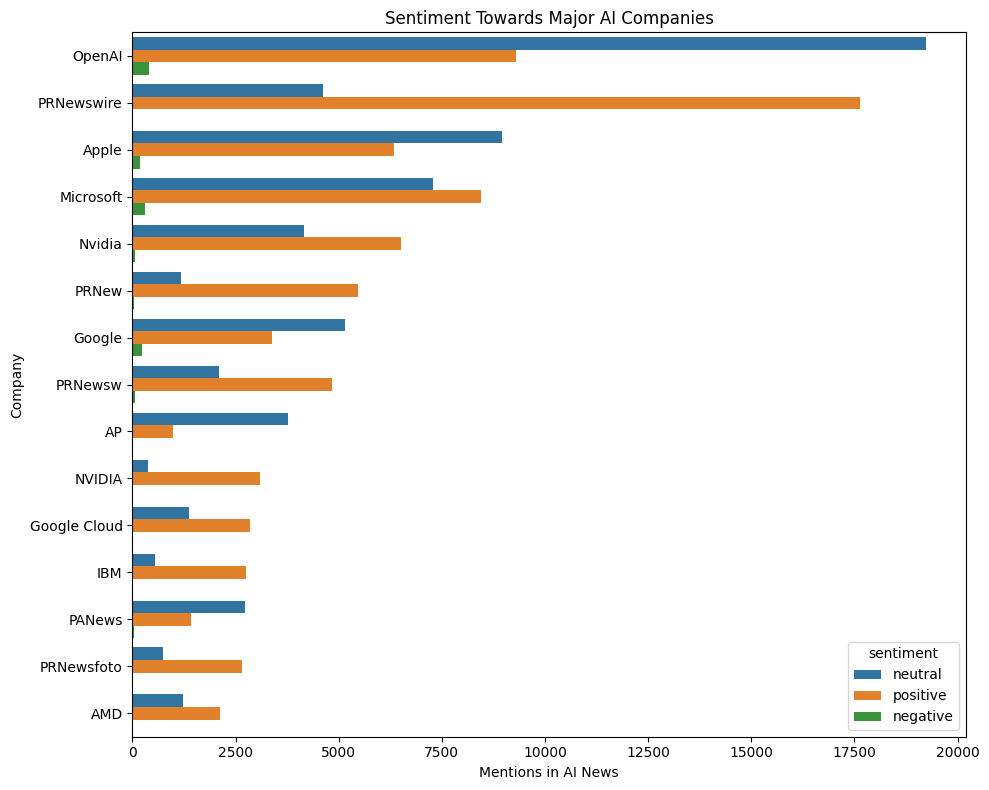

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.barplot(
    data=entity_sentiment_top,
    x="count",
    y="entity_text",
    hue="sentiment"
)

plt.title("Sentiment Towards Major AI Companies")
plt.xlabel("Mentions in AI News")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

## Sentiment Over Time

In [15]:
df_sent["date"] = pd.to_datetime(df_sent["date"])

In [16]:
sentiment_time = (
    df_sent
    .groupby([
        pd.Grouper(key="date", freq="M"),
        "sentiment"
    ])
    .size()
    .reset_index(name="count")
)

sentiment_time.head()

/tmp/ipykernel_231/2292461609.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="date", freq="M"),


,date,sentiment,count
0,2022-01-31 00:00:00+00:00,negative,1
1,2022-01-31 00:00:00+00:00,neutral,108
2,2022-01-31 00:00:00+00:00,positive,115
3,2022-02-28 00:00:00+00:00,negative,2
4,2022-02-28 00:00:00+00:00,neutral,75


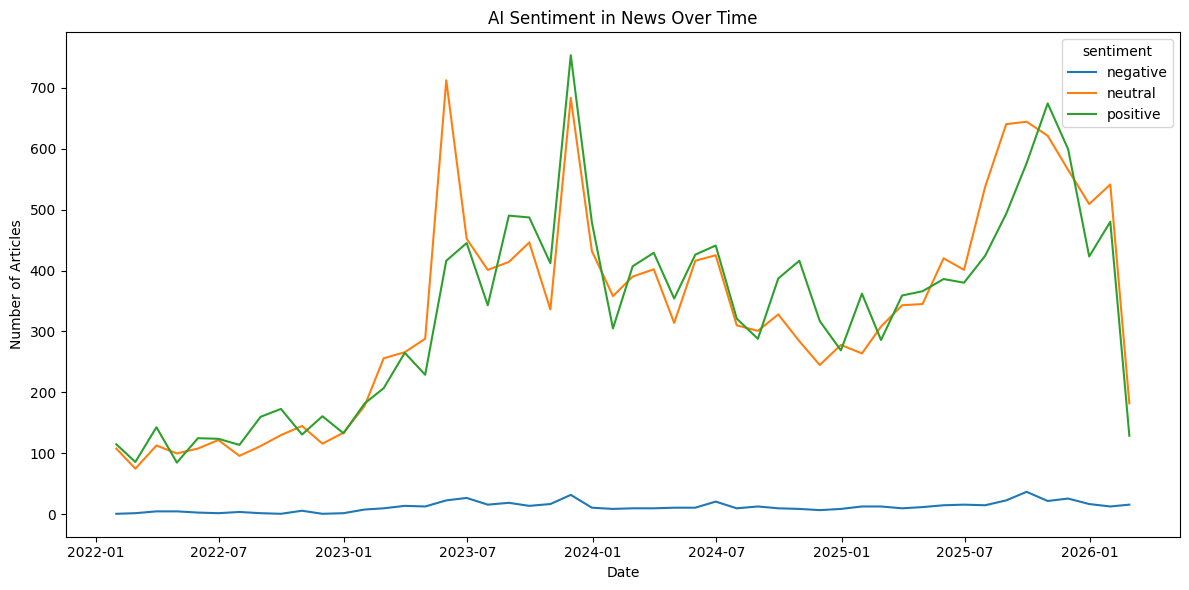

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.lineplot(
    data=sentiment_time,
    x="date",
    y="count",
    hue="sentiment"
)

plt.title("AI Sentiment in News Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()

In [18]:
sentiment_time["total"] = (
    sentiment_time
    .groupby("date")["count"]
    .transform("sum")
)

sentiment_time["pct"] = sentiment_time["count"] / sentiment_time["total"]

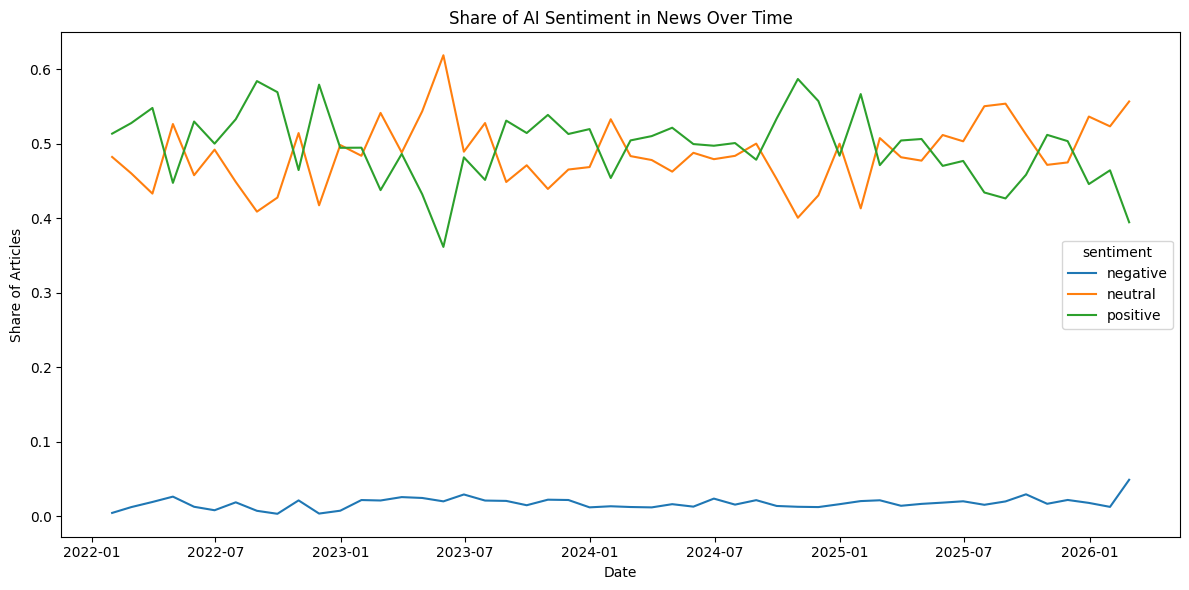

In [19]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sentiment_time,
    x="date",
    y="pct",
    hue="sentiment"
)

plt.title("Share of AI Sentiment in News Over Time")
plt.xlabel("Date")
plt.ylabel("Share of Articles")

plt.tight_layout()
plt.show()

In [20]:
sentiment_time.to_parquet(
    ARTIFACTS_DIR / "sentiment_over_time.parquet",
    index=False
)